In [1]:
#Test Benchmark. Used to explore concepts
import torch
import torch.distributions as dist

CUDA = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

P = 400
R = 4
C = 4

TRUE_ALPHA = dist.Normal(
                    loc = torch.zeros(R,C - 1) + torch.eye(R, C-1),
                    scale = torch.ones(R,C - 1) * 0.5
                ).sample().to(CUDA)
TRUE_ALPHA = torch.cat([TRUE_ALPHA, torch.zeros(R).to(CUDA)[:, None]], dim=1)

TRUE_DENSITY = dist.Gamma(6, 2).sample((R,)).to(CUDA)

TRUE_BETA = dist.Dirichlet( 
                    concentration = TRUE_ALPHA.exp() * TRUE_DENSITY[:, None]
                ).sample((P,))

POPULATION = dist.Poisson(rate = 4000).sample((P,)).to(CUDA)

X = dist.Dirichlet(
                    concentration = torch.ones(R)
                ).sample((P,)).to(CUDA)
X = (X * POPULATION[ : , None ]).ceil()

T = (X[: , :, None] * TRUE_BETA).sum(dim=1).round()

def display_transition_matrix(p_idx, TRUE_BETA, TRUE_ALPHA, TRUE_DENSITY, X, T):
    
    R, C = TRUE_ALPHA.shape

    row_names = [f"Group {r}" for r in range(R)]
    col_names = [f"Party {c}" for c in range(C)]

    beta  = TRUE_BETA[p_idx]          # (R, C)
    alpha = TRUE_ALPHA                 # (R, C)
    density = TRUE_DENSITY
    x_row = X[p_idx]                  # (R,)
    t_col = T[p_idx]                  # (C,)

    # ── Column widths ───────────────────────────────────────────────
    cell_w   = 18          # width of each data cell
    label_w  = 14          # width of the row-label column
    rowsum_w = 16          # width of the row-sum column

    # ── Header ──────────────────────────────────────────────────────
    col_header = "".join(f"{name:^{cell_w}}" for name in col_names)
    header = (f"\n  Transition Matrix — Precinct {p_idx}\n"
              f"  beta value  (alpha concentration)\n")
    divider = "─" * (label_w + cell_w * C + rowsum_w)

    print(header)
    print(f"{'':^{label_w}}{col_header}{'X (group N)':^{rowsum_w}}")
    print(divider)

    # ── Data rows ───────────────────────────────────────────────────
    for r in range(R):
        row_label = f"{row_names[r]:<{label_w}}"
        cells = ""
        for c in range(C ):
            b = beta[r, c].item()
            if c != C - 1 : a = alpha[r, c].item()
            else: a = density[r].item()
            cell = f"{b:.3f} ({a:.2f})"
            cells += f"{cell:^{cell_w}}"
        x_val = f"{x_row[r].item():>6.0f}"
        print(f"{row_label}{cells}{x_val:^{rowsum_w}}")

    print(divider)

    # ── Column sums (T) ─────────────────────────────────────────────
    col_sums = "".join(
        f"{t_col[c].item():^{cell_w}.0f}" for c in range(C)
    )
    total = t_col.sum().item()
    print(f"{'T (votes)':^{label_w}}{col_sums}{total:^{rowsum_w}.0f}")
    print()

display_transition_matrix(1, TRUE_BETA, TRUE_ALPHA, TRUE_DENSITY, X, T)


  Transition Matrix — Precinct 1
  beta value  (alpha concentration)

                   Party 0           Party 1           Party 2           Party 3        X (group N)   
──────────────────────────────────────────────────────────────────────────────────────────────────────
Group 0          0.346 (0.45)      0.515 (0.62)     0.045 (-0.72)      0.095 (3.12)          1877     
Group 1          0.208 (0.48)      0.675 (1.38)     0.031 (-0.34)      0.087 (3.54)           707     
Group 2          0.160 (0.04)     0.142 (-0.11)      0.631 (1.48)      0.067 (2.51)           135     
Group 3          0.140 (0.32)      0.356 (0.99)      0.271 (0.20)      0.232 (2.21)          1278     
──────────────────────────────────────────────────────────────────────────────────────────────────────
  T (votes)          997               1919              537               545              3998      



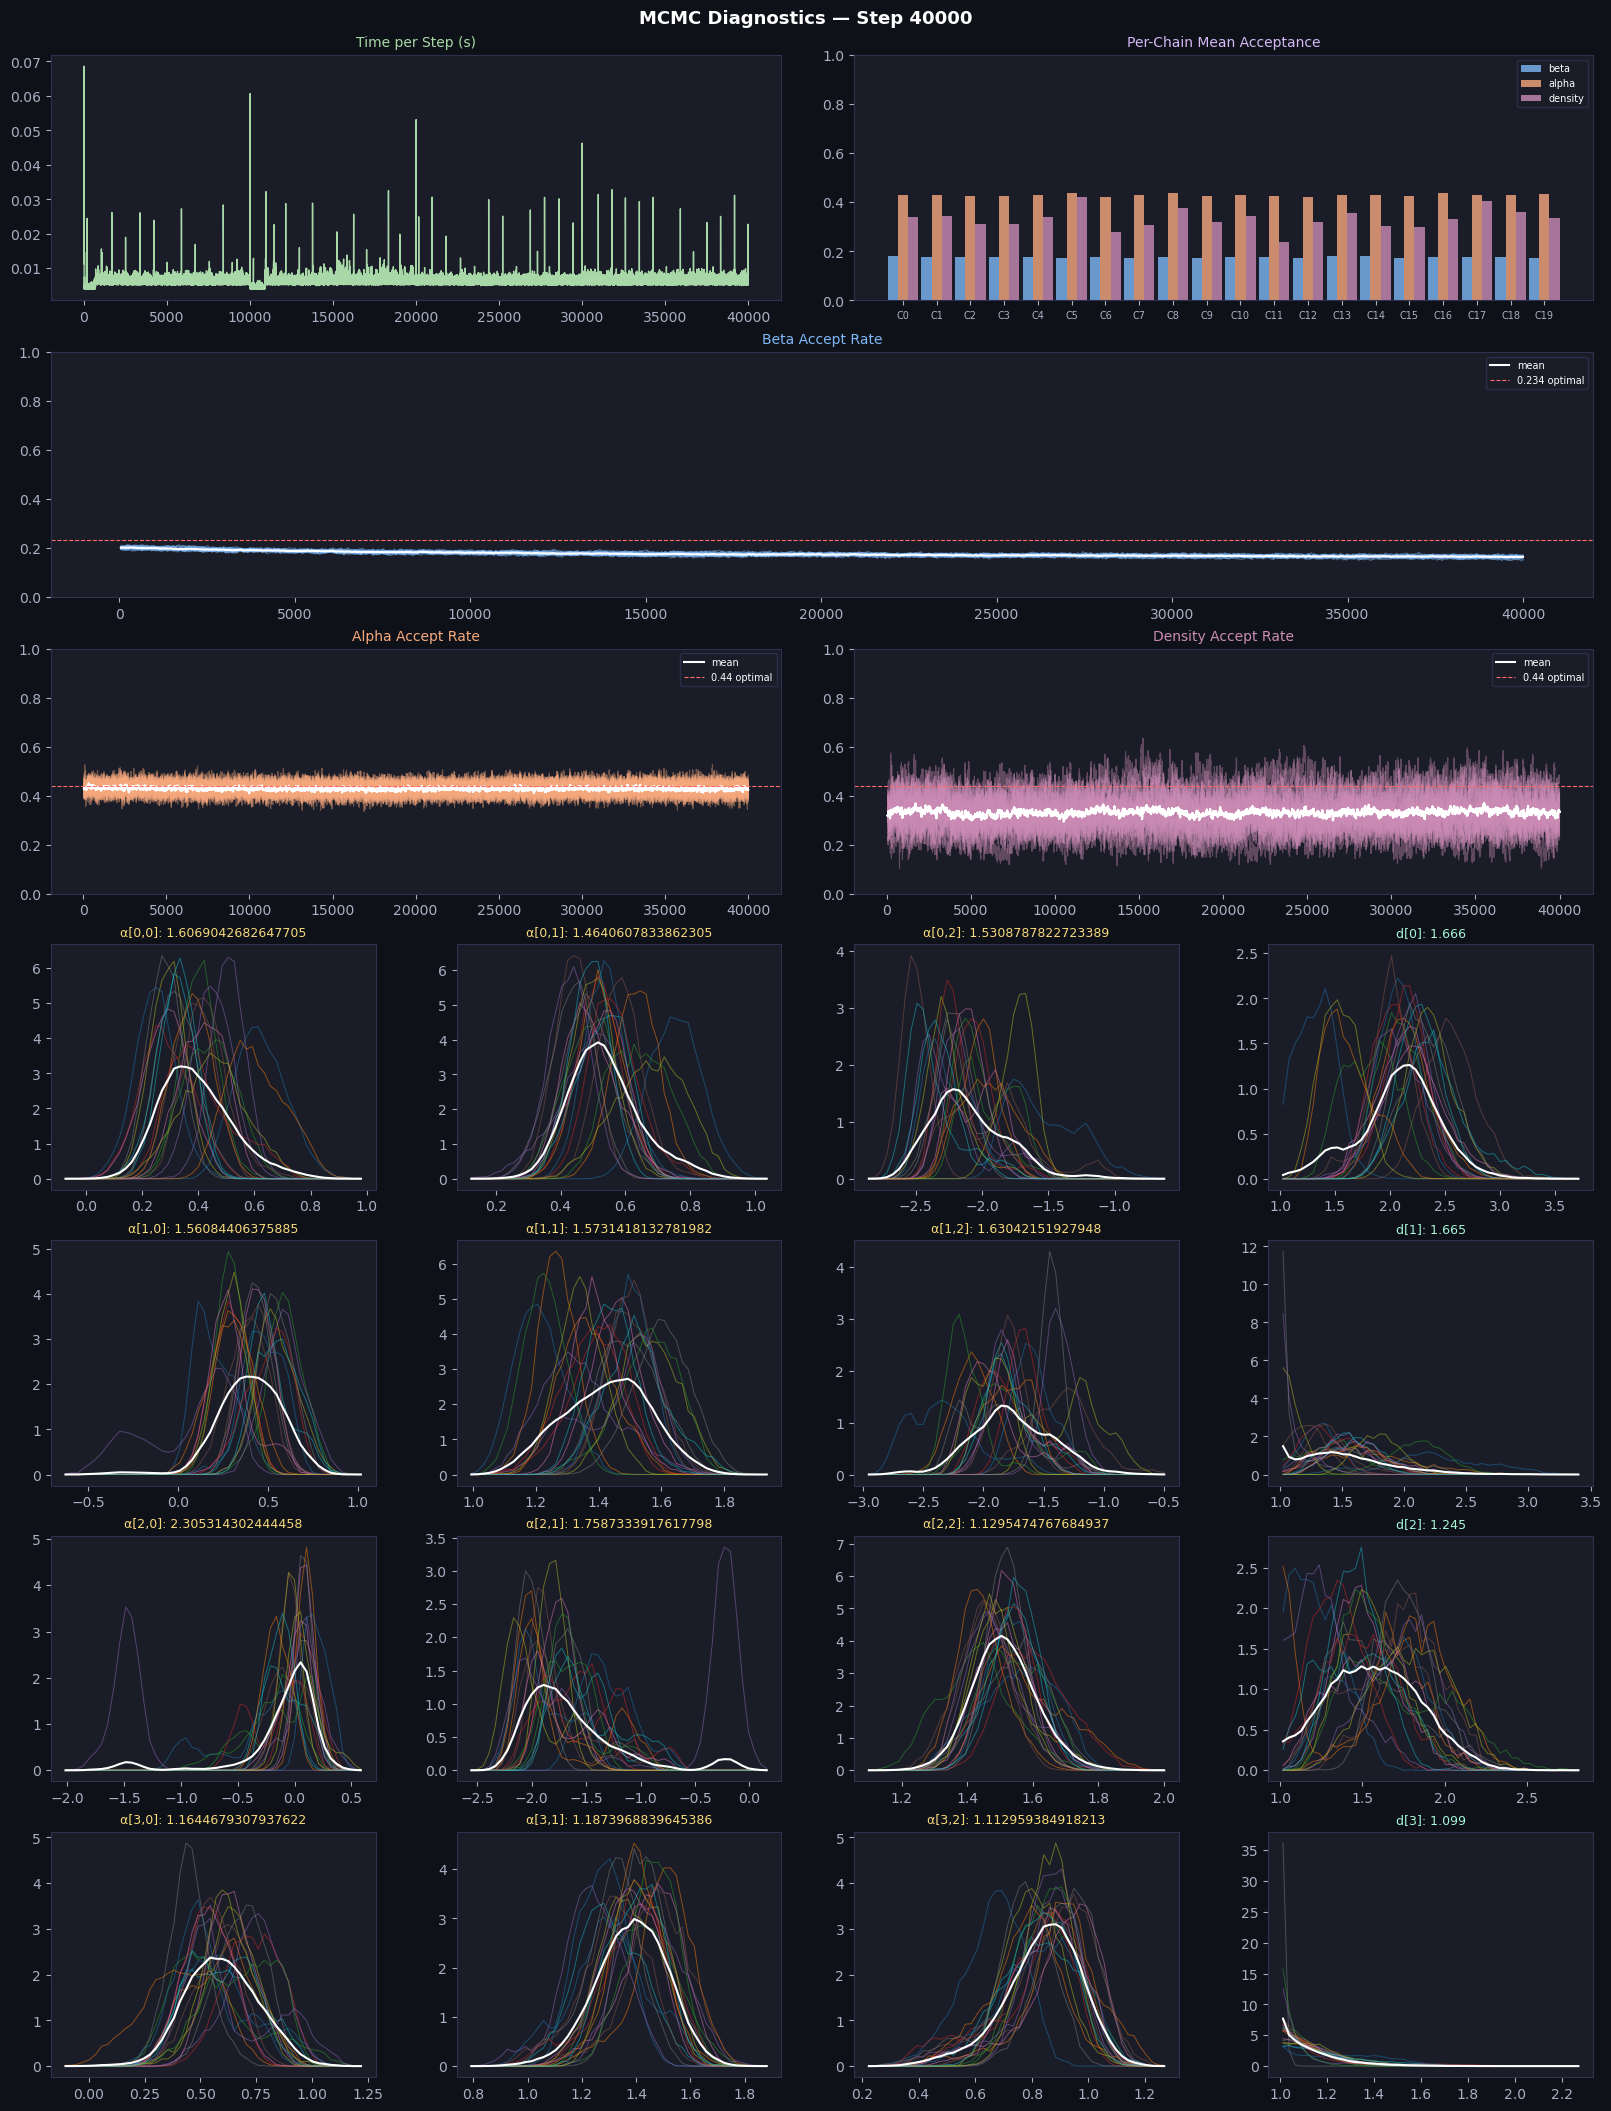

Steps:  40%|###9      | 39999/99999 [06:33<06:30, 153.56it/s]

KeyboardInterrupt: 

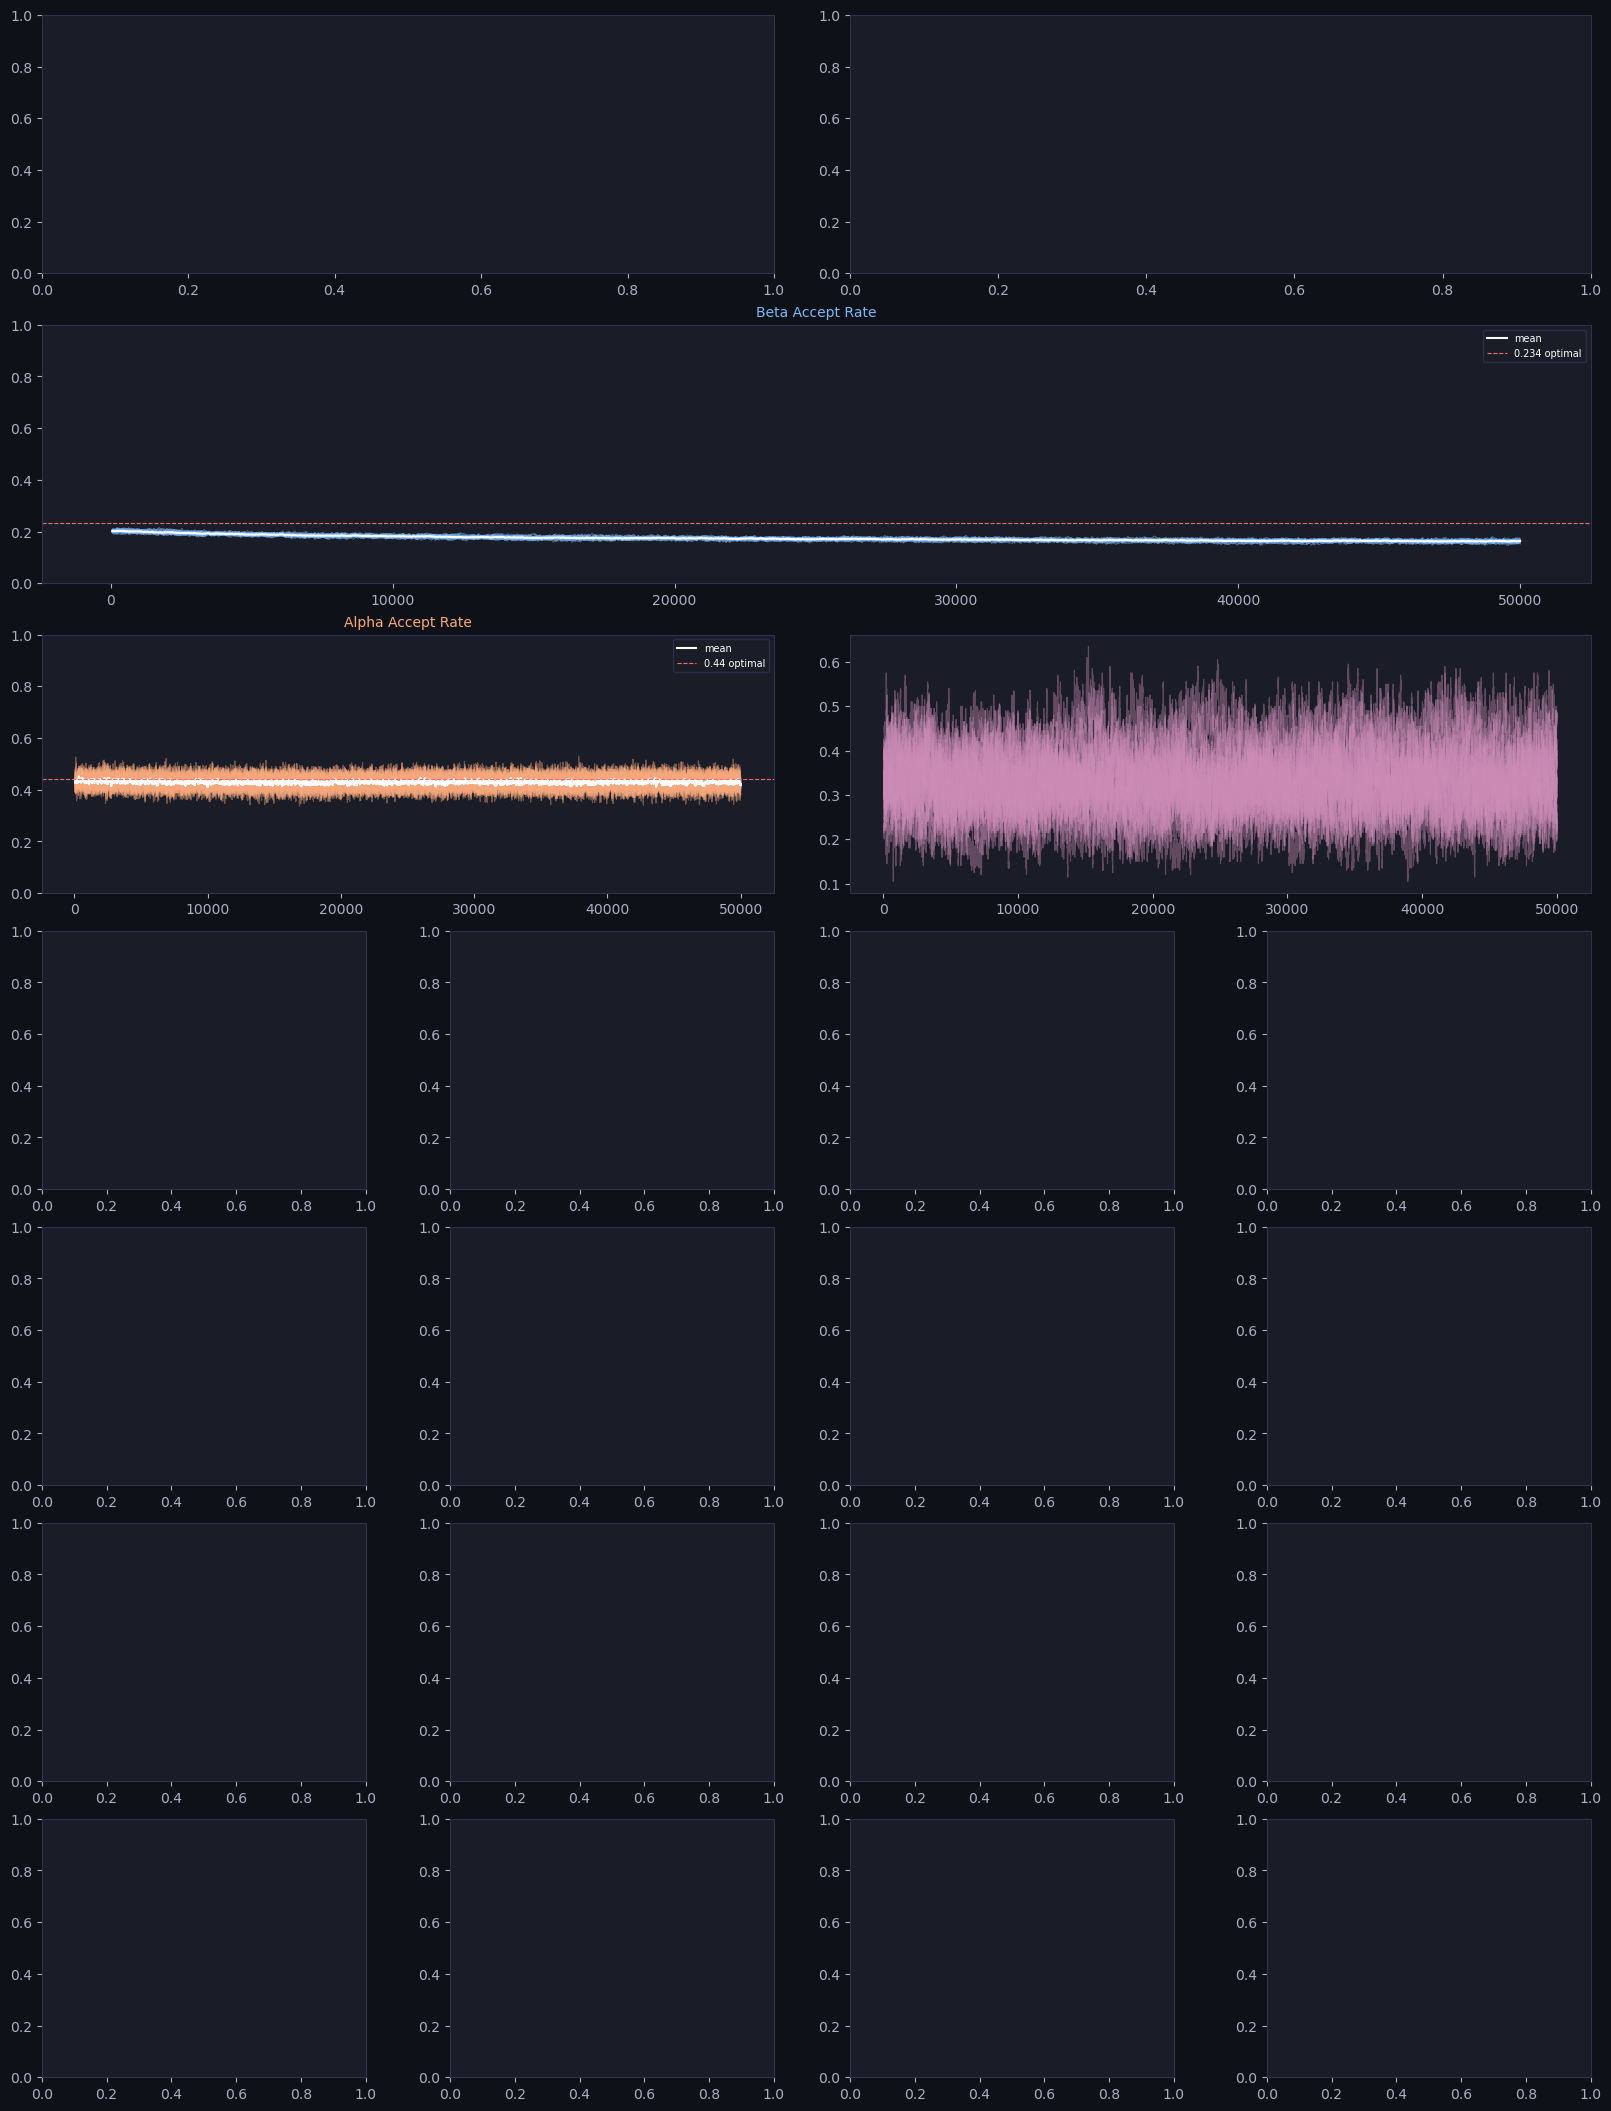

In [3]:
from MCMC_heteroproposals import EI_MCMC

ALPHAS, DENSITIES = EI_MCMC(X, T, 20, 100000, 10000, 0, (0,1), (4,2), 200, 0.3, 0.2, checkpoint=10000, save_betas=False)

In [ ]:
import pickle

#with open("results/ALPHAS.pkl", "wb") as f: pickle.dump(ALPHAS.cpu())
#with open("results/ALPHAS.pkl", "rb") as f: ALPHAS = pickle.load(f)